In [1]:
import uproot
import awkward as ak
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

import sys
sys.path.append("/home/xzcqsfhu/lundtoptagger/")
from plotting.utils_plots_matplotlib import hist_with_errors
from tools.GNN_model_weight.utils_newdata import JSD

In [2]:
tree_name = "FlatSubstructureJetTree"
train_file_paths = ["/home/xzcqsfhu/lundtoptagger/qg_analysis_data/jet2m_ParT/data/part1_2percent/data_dijet_ParT_batch*_ln_kT_cut_None.root"]
test_file_paths = ["/home/xzcqsfhu/lundtoptagger/qg_analysis_data/jet2m_ParT/data/part0_1percent/data_dijet_ParT_batch*_ln_kT_cut_None.root"]


train_files_paths_with_trees = [f"{path}:{tree_name}" for path in train_file_paths]
test_files_paths_with_trees = [f"{path}:{tree_name}" for path in test_file_paths]
train_data = uproot.concatenate(train_files_paths_with_trees)
test_data = uproot.concatenate(test_files_paths_with_trees)

dsid_weight_map = {    
    364700: 1.0,               
    364701: 1.0,               
    364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
    364703: 26452000.0   * 0.011653  / 24.124114769654568,
    364704: 254610.0 * 0.013358 / 0.6689032716609136,
    364705: 4553.5   * 0.014513 / 0.021711071504255608, 
    364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
    364707: 16.214 * 0.011092 / 7.647190915207464e-05,
    364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
    364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
    364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
    364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
    364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
    426345: 950.41935,
    801471: 0.0189,
    801859: 12.45803
    
}

train_weights = np.array([dsid_weight_map[dsid] for dsid in train_data["EventInfo_mcChannelNumber"]]) * train_data["EventInfo_mcEventWeight"]
test_weights = np.array([dsid_weight_map[dsid] for dsid in test_data["EventInfo_mcChannelNumber"]]) * test_data["EventInfo_mcEventWeight"]

plt.figure(figsize=(10, 7), dpi=100)
plt.hist(train_data["fjet_pt"], weights=train_weights, bins=50, range=(160,1300), density=True, linewidth=2, label="Train Data", histtype="step")
plt.hist(test_data["fjet_pt"], weights=test_weights, bins=50, range=(160,1300), density=True, linewidth=1, label="Test Data", histtype="step")
plt.xlabel("Jet $p_{T}$ [GeV]")
plt.ylabel("Normalized Entries (Weighted)")
plt.title("Jet $p_{T}$ Distribution")
plt.yscale("log")
plt.legend(loc='upper right', frameon=False, fontsize='small')

FileNotFoundError: file not found

    ['/home/xzcqsfhu/lundtoptagger/qg_analysis_data/jet2m_ParT/data/part1_2percent/data_dijet_ParT_batch*_ln_kT_cut_None.root:FlatSubstructureJetTree']

Files may be specified as:
   * str/bytes: relative or absolute filesystem path or URL, without any colons
         other than Windows drive letter or URL schema.
         Examples: "rel/file.root", "C:\abs\file.root", "http://where/what.root"
   * str/bytes: same with an object-within-ROOT path, separated by a colon.
         Example: "rel/file.root:tdirectory/ttree"
   * pathlib.Path: always interpreted as a filesystem path or URL only (no
         object-within-ROOT path), regardless of whether there are any colons.
         Examples: Path("rel:/file.root"), Path("/abs/path:stuff.root")

Functions that accept many files (uproot.iterate, etc.) also allow:
   * glob syntax in str/bytes and pathlib.Path.
         Examples: Path("rel/*.root"), "/abs/*.root:tdirectory/ttree"
   * dict: keys are filesyst

In [3]:
score_files_paths = [
    "/home/xzcqsfhu/lundtoptagger/qg_analysis_data/jet2m_ParT/scores/160_1300_pt_0_1.2_eta_comparison/Final_Scores_ParT_1%_test_kTNone.root"
]

json_file = [
    "/home/xzcqsfhu/lundtoptagger/meta.json"
]

tree_name = "FlatSubstructureJetTree"

In [4]:
import json

# Load metadata from the json file specified in the previous cell
with open(json_file[0], 'r') as f:
    meta_data = json.load(f)

dsid_numerators = {}

if "by_dsid" in meta_data:
    for dsid, values_list in meta_data["by_dsid"].items():
        if isinstance(values_list, list) and len(values_list) > 0:
            values = values_list[0]
            
            xsec = values.get('cross_section_pb', values.get('xsec'))
            genfilteff = values.get('genFiltEff', values.get('genfilteff'))
            kfactor = values.get('kfactor', 1.0)
            
            if xsec is not None and genfilteff is not None:
                # Store numerator = xsec * genfilteff * kfactor
                # sum_of_weight is not in JSON, will be calculated from data
                dsid_numerators[int(dsid)] = xsec * genfilteff * kfactor
            else:
                 print(f"Warning: Missing required values for dsid {dsid}. Found keys: {list(values.keys())}")
else:
    print("Error: 'by_dsid' key not found in JSON data")

print(f"Created dsid_numerators with {len(dsid_numerators)} entries")

Created dsid_numerators with 13 entries


In [5]:
# dsid_weight_map = {    
#     # 364700: , 78050000000.0 * 0.9753257 / 
#     # 364701: , # To be calculated
#     364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
#     364703: 26452000.0   * 0.011653  / 24.124114769654568,
#     364704: 254610.0 * 0.013358 / 0.6689032716609136,
#     364705: 4553.5   * 0.014513 / 0.021711071504255608, 
#     364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
#     364707: 16.214 * 0.011092 / 7.647190915207464e-05,
#     364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
#     364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
#     364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
#     364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
#     364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
#     426345: 950.41935,
#     801471: 0.0189,
#     801859: 12.45803
# }
# for key, val in dsid_weight_map.items():
#     print(f"key: {key}, val: {val}")

# Manual dsid_weight_map commented out to use the one calculated from the json file above
# dsid_weight_map = {
#     364703: 12823.94988,
#     364704: 5081.45927,
#     364705: 3017.75098,
#     364706: 4371.00012,
#     364707: 2349.98631,
#     426345: 950.41935,
#     801471: 0.0189,
#     801859: 12.45803,
#     801661: 1.0,
#     364702: 1.0,

#     364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
#     364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
#     364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
#     364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
#     364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
# }

In [6]:
score_files_paths_with_trees = [f"{path}:{tree_name}" for path in score_files_paths]
data = uproot.concatenate(score_files_paths_with_trees)

In [7]:
# This give the same output as just entering the variable name in a notebook cell
from IPython.display import display
display(data.fields)

['fjet_m',
 'fjet_pt',
 'fjet_eta',
 'fjet_phi',
 'fjet_truth_label',
 'fjet_Nconst',
 'fjet_Nconst_Charged',
 'parT_score',
 'EventInfo_mcEventWeight',
 'EventInfo_mcChannelNumber',
 'labels',
 'fjet_LundNet_SRJ_eta12_pt160_1300_1%_batch4500_lr0.0004_e17_score',
 'fjet_LundNet_SRJ_eta12_pt160_1300_2%_batch4500_lr0.0004_e17_score',
 'fjet_LundNet_SRJ_eta12_pt160_1300_2%_batch4500_lr0.0001_e15_score',
 'fjet_LundNet_SRJ_eta12_pt160_1300_2%_batch1024_lr0.0004_e20_score',
 'fjet_LundNet_SRJ_eta12_pt160_1300_2%_batch1024_lr0.0001_e17_score']

In [8]:
print("Signal jets:", np.sum(data["labels"]==1))
print("Background jets:", np.sum(data["labels"]==0))
print("Total:", len(data))

Signal jets: 668518
Background jets: 988194
Total: 1656712


In [9]:
import os
print(os.getcwd())
import glob
print(glob.glob("numpy.py"))

/home/xzcqsfhu/lundtoptagger/submit
[]


In [10]:
# Weight = mceventweight * xsec * genfilteff * kfactor / sum_of_weight
# Per instructions: Using weight map based ONLY on numerators (effectively assuming sum_of_weights = 1)

mc_channel_number = ak.to_numpy(data["EventInfo_mcChannelNumber"])
mc_event_weight = ak.to_numpy(data["EventInfo_mcEventWeight"])
unique_dsids = np.unique(mc_channel_number)

# 1. Determine weight factors per DSID
dsid_factors = {}

for dsid in unique_dsids:
    # Just use the numerator: xsec * genfilteff * kfactor
    dsid_factors[int(dsid)] = dsid_numerators.get(int(dsid), 0.0)

# 2. Apply weights
# Initialize weights array
weights = np.zeros_like(mc_event_weight)

# Apply factor for each DSID
for dsid, factor in dsid_factors.items():
    mask = (mc_channel_number == dsid)
    weights[mask] = factor * mc_event_weight[mask]

print(f"Calculated weights for {len(weights)} events using only numerators.")
print(f"Mean weight: {np.mean(weights)}")
print(weights[:20])

Calculated weights for 1656712 events using only numerators.
Mean weight: 655943.9357928467
[7.61241709e+10 7.61241709e+10 7.61241709e+10 7.61241709e+10
 7.61241709e+10 7.61241709e+10 7.61241709e+10 7.61241709e+10
 7.61241709e+10 7.61241709e+10 7.61241709e+10 7.61241709e+10
 7.61241709e+10 7.61241709e+10 1.90636891e+09 1.90636891e+09
 1.90636891e+09 1.90636891e+09 1.90636891e+09 1.90636891e+09]


In [11]:
dsid_weight_map = {    
    364700: 1.0,               
    364701: 1.0,               
    364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
    364703: 26452000.0   * 0.011653  / 24.124114769654568,
    364704: 254610.0 * 0.013358 / 0.6689032716609136,
    364705: 4553.5   * 0.014513 / 0.021711071504255608, 
    364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
    364707: 16.214 * 0.011092 / 7.647190915207464e-05,
    364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
    364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
    364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
    364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
    364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
    426345: 950.41935,
    801471: 0.0189,
    801859: 12.45803
    
}

In [12]:
# Weight = mceventweight * xsec * genfilteff * kfactor / sum_of_weight
# dsid_weight_map contains the pre-calculated factor (xsec * genfilteff * kfactor / sum_of_weight)
weights = np.array([dsid_weight_map[dsid] for dsid in data["EventInfo_mcChannelNumber"]]) * data["EventInfo_mcEventWeight"]

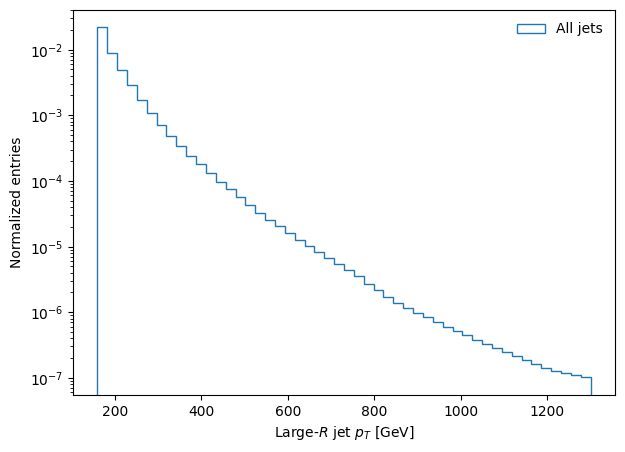

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5), dpi=100)
plt.hist(data["fjet_pt"], weights=weights, bins=50, range=(160, 1300), density=True, histtype="step", label="All jets")
plt.xlabel(r"Large-$R$ jet $p_T$ [GeV]")
plt.ylabel("Normalized entries")
plt.yscale("log")
plt.legend(frameon=False)
plt.show()

In [14]:
def calc_best_discriminant(truth_labels, pqcd, phbb, phcc, ptop, step=0.01):
    # TODO: generalise to arbitrary number of classes
    values = np.arange(step, 1.0, step)
    xx, yy = np.meshgrid(values, values)
    mask = xx + yy < 1

    best_auc = 0
    for fhbb, fhcc in tqdm(np.stack([xx[mask], yy[mask]], axis=-1)):
        denoms = fhbb * phbb + fhcc * phcc + (1 - fhbb - fhcc) * pqcd
        scores = np.log(ptop / denoms)
        auc = roc_auc_score(truth_labels, scores)

        # TODO: is finding the best AUC the right thing to do?
        # TODO: does the ROC curve calculation work correctly if the scores are not normalized to (0,1)?
        # (important for this function and also for the plots later on)
        # TODO: Should use data weights in this calculation!
        if auc > best_auc:
            best_auc = auc
            best_fhbb, best_fhcc = fhbb, fhcc

    return best_auc, best_fhbb, best_fhcc

In [15]:
do_calc_best_discriminant = False
if do_calc_best_discriminant:
    GN3X_best_auc, best_fhbb, best_fhcc = calc_best_discriminant(
        data["labels"],
        data["GN3X_pqcd"],
        data["GN3X_phbb"],
        data["GN3X_phcc"],
        data["GN3X_ptop"],
        step=0.01
    )
    print(f"GN3X best AUC: {GN3X_best_auc:.4f}, fhbb: {best_fhbb:.4f}, fhcc: {best_fhcc:.4f}")
# GN3X best AUC: 0.9349, fhbb: 0.0100, fhcc: 0.0400

In [16]:
if do_calc_best_discriminant:
    fhbb = best_fhbb
    fhcc = best_fhcc
else:
    fhbb = 0.05
    fhcc = 0.05

try:
    if "GN3X_pqcd" in data.fields:
        pqcd = data["GN3X_pqcd"]
    else:
        # Calculate pqcd as sum of components if not present
        pqcd = data["GN3X_pqcdbb"] + data["GN3X_pqcdbx"] + data["GN3X_pqcdcx"] + data["GN3X_pqcdll"]

    denoms = fhbb * data["GN3X_phbb"] + fhcc * data["GN3X_phcc"] + (1 - fhbb - fhcc) * pqcd
    gn3x_scores = np.log(data["GN3X_ptop"] / denoms)
except Exception as e:
    print(f"Error calculating GN3X scores: {e}")
    gn3x_scores = None

Error calculating GN3X scores: no field 'GN3X_pqcdbb' in record with 16 fields


In [17]:
models = {    
    # 2% Stats - Hyperparameter Comparison
    "LundNet 2% (4500 Batch, 4.0e-4 LR)": {
        "scores": data["fjet_LundNet_SRJ_eta12_pt160_1300_2%_batch4500_lr0.0004_e17_score"]
    },
    "LundNet 2% (1.0e-4 LR)": {
        "scores": data["fjet_LundNet_SRJ_eta12_pt160_1300_2%_batch4500_lr0.0001_e15_score"]
    },
    "LundNet 2% (1024 Batch)": {
        "scores": data["fjet_LundNet_SRJ_eta12_pt160_1300_2%_batch1024_lr0.0004_e20_score"]
    },
    "LundNet 2% (1024 Batch, 1.0e-4 LR)": {
        "scores": data["fjet_LundNet_SRJ_eta12_pt160_1300_2%_batch1024_lr0.0001_e17_score"]
    },
    
    # Colleague's Baseline
    "ParT (Baseline)": {
        "scores": data["parT_score"]
    }
}

# Set tick format for all plots
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams["axes.formatter.use_mathtext"] = True

# Increase tick mark size
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3

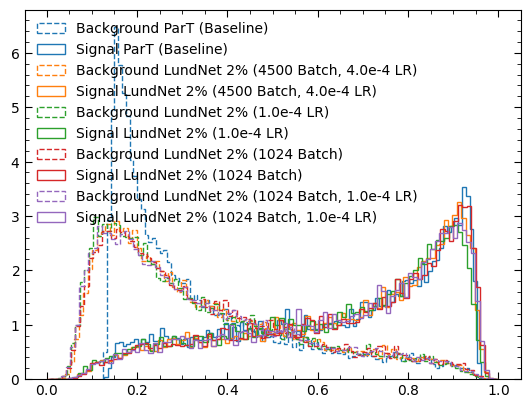

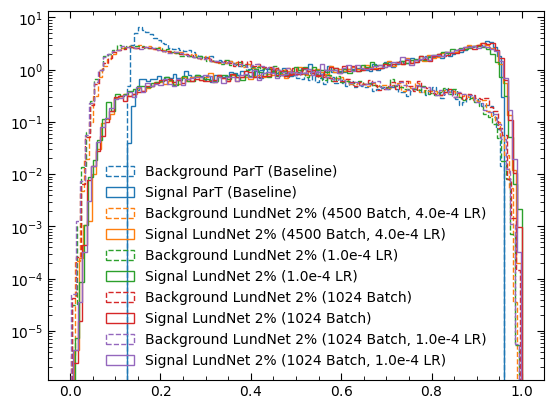

In [18]:
# Extract scores and labels
labels = data["labels"]

hist_params = dict(
    bins = 100,
    # range = (0, 1),
    density = True,
    # alpha = 0.5,
    histtype = "step"
)

selected_models = ["ParT (Baseline)", "LundNet 2% (4500 Batch, 4.0e-4 LR)", "LundNet 2% (1.0e-4 LR)", "LundNet 2% (1024 Batch)", "LundNet 2% (1024 Batch, 1.0e-4 LR)"]
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
    plt.yscale('log')
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

#selected_models = ["GN3X"]
#for i, model in enumerate(selected_models):
#    scores = models[model]["scores"]
#    hist_params["color"] = f"C{i}"
#    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
#    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
#plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
#plt.show()
# for i, model in enumerate(selected_models):
#     scores = models[model]["scores"]
#     hist_params["color"] = f"C{i}"
#     plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
#     plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
#     plt.yscale('log')
# plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

In [19]:
# TODO: working point should be calculated differently if weights are used - sum of weights of signal jets with score above threshold should be 50% of total weight of signal jets
# it doesn't make a difference for currently used signal samples because their MC weights are all equal to 1, but this is something to keep in mind for future samples
for model in models:
    # Sort scores corresponding to signal jets
    scores = models[model]["scores"]
    if scores is None:
        print(f"Skipping {model} because scores are None")
        continue

    signal_scores = scores[labels == 1]
    sorted_signal_scores = np.sort(signal_scores)

    # Determine the threshold for 50% signal efficiency
    signal_efficiency = 0.5
    threshold_index = int(signal_efficiency * len(sorted_signal_scores))
    threshold_score = sorted_signal_scores[threshold_index]

    models[model]["threshold_score"] = threshold_score
    print(f"50% signal efficiency threshold for {model}:", threshold_score)

50% signal efficiency threshold for LundNet 2% (4500 Batch, 4.0e-4 LR): 0.7387158870697021
50% signal efficiency threshold for LundNet 2% (1.0e-4 LR): 0.736798882484436


50% signal efficiency threshold for LundNet 2% (1024 Batch): 0.7452394366264343
50% signal efficiency threshold for LundNet 2% (1024 Batch, 1.0e-4 LR): 0.7461549043655396
50% signal efficiency threshold for ParT (Baseline): 0.7144088


In [20]:
var_params = {
    "fjet_m":  {"title": "Large-$R$ jet mass [GeV]",  "bins": 45, "range": (50, 500) },
    "fjet_pt": {"title": "Large-$R$ jet $p_T$ [GeV]", "bins": 30, "range": (0, 3000)},
}

In [21]:
# selected_models = models.keys()  # Use all models for now
# selection = (data["fjet_pt"] > 350) & (np.abs(data["fjet_eta"] < 2))
# plot_signal_after_tagging = False
# plot_errorbars = True
# calc_jsd = False

# plot_params = {
#     "lin": {
#         "yscale": "linear",
#         "ylim": (0, 0.06),
#     },
#     "log": {
#         "yscale": "log",
#         "ylim": (1e-5, 10),
#     }
# }

# for params in plot_params.values():
#     for var in var_params:
#         fig, ax = plt.subplots(figsize=(6.6, 6.6), dpi=200)

#         var_data = data[var]
#         hist_params = dict(
#             bins = var_params[var]["bins"],
#             range = var_params[var]["range"],
#             density = True,
#         )

#         # QCD background: shaded dark gray with black outline
#         bkg_counts = plt.hist(var_data[(labels==0) & selection], weights=weights[(labels==0) & selection], label="QCD background", color="dimgray", alpha=0.7, **hist_params)[0]
#         plt.hist(var_data[(labels==0) & selection], weights=weights[(labels==0) & selection], histtype="step", color="black", linewidth=1.2, **hist_params)
#         # Signal: fill with neutral, light colour
#         plt.hist(var_data[(labels==1) & selection], weights=weights[(labels==1) & selection], label="Signal", color="lightsteelblue", alpha=0.6, **hist_params)
#         plt.hist(var_data[(labels==1) & selection], weights=weights[(labels==1) & selection], histtype="step", color="slategray", linewidth=1.2, **hist_params)

#         for i, model in enumerate(selected_models):
#             tagged_as_signal = models[model]["scores"] > models[model]["threshold_score"]

#             if i !=0 and calc_jsd:
#                 bkg_counts_tagged = np.histogram(
#                     ak.to_numpy(var_data[(labels==0) & tagged_as_signal & selection]),
#                     weights=ak.to_numpy(weights[(labels==0) & tagged_as_signal & selection]),
#                     **hist_params
#                 )[0]
#                 JSD_value = JSD(bkg_counts, bkg_counts_tagged)*100  # TODO: maybe shouldn't be expressed as a percentage
#                 JSD_label = f", JSD = {JSD_value:.2f}%"
#             else:
#                 JSD_label = ""

#             if plot_errorbars:
#                 extra_args = dict(fmt='.')
#                 hist_plot_func = hist_with_errors
#             else:
#                 extra_args = dict(histtype="step", linestyle='-' if i==0 else '--', linewidth=1.5)
#                 hist_plot_func = plt.hist
#             hist_plot_func(
#                 var_data[(labels==0) & tagged_as_signal & selection],
#                 weights=weights[(labels==0) & tagged_as_signal & selection],
#                 label=f"QCD tagged as signal{JSD_label}\n({model})",
#                 **hist_params, **extra_args
#             )
#             if plot_signal_after_tagging:
#                 hist_plot_func(
#                     var_data[(labels==1) & tagged_as_signal & selection],
#                     weights=weights[(labels==1) & tagged_as_signal & selection],
#                     label=f"Signal tagged as signal{JSD_label}\n({model})",
#                     **hist_params, **extra_args
#                 )

#         # Add ATLAS label
#         atlas_label = r"ATLAS"
#         atlas_sim = r"Simulation Internal"
#         atlas_info = r"$\sqrt{s} = 13$ TeV, $top$ tagging"  # TODO: make it autimatically use W or top based on selected config
#         jet_info = r"anti-$k_t$ $R=1.0$ UFO Soft-Drop CS+SK jets"
#         selection_info = r"$\epsilon^{\mathrm{rel}}_{\mathrm{sig}}=50\%,\ p_T > 350$ GeV, $| \eta | < 2.0$" # TODO: make this dynamic based on selection, and for the pT plot show the mass cut
#         text_args = {"transform": ax.transAxes, "va": 'top'}
#         ax.text(0.04, 0.97, atlas_label,    fontsize=12, **text_args, fontweight='bold', style='italic')
#         ax.text(0.20, 0.97, atlas_sim,      fontsize=12, **text_args)
#         ax.text(0.04, 0.92, atlas_info,     fontsize=11, **text_args)
#         ax.text(0.04, 0.87, jet_info,       fontsize=11, **text_args)
#         ax.text(0.04, 0.82, selection_info, fontsize=11, **text_args)

#         plt.xlim(var_params[var]["range"])
#         plt.xlabel(var_params[var]["title"])
#         plt.ylabel("Fraction of jets / 10 GeV")  # TODO: make this dynamic based on bin width, and different for the mass and pT plots
#         plt.yscale(params["yscale"])
#         plt.ylim(params["ylim"])
#         # plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
#         plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.45, 0.75))
#         plt.show()

In [22]:
mass = data["fjet_m"]
pt = data["fjet_pt"]
eta = data["fjet_eta"]

mass_cuts = [
    (0, float('inf')),
]
pt_min = 160
pt_max = 1300
eta_min = 0
eta_max = 1.2
# eta_max = float('inf')

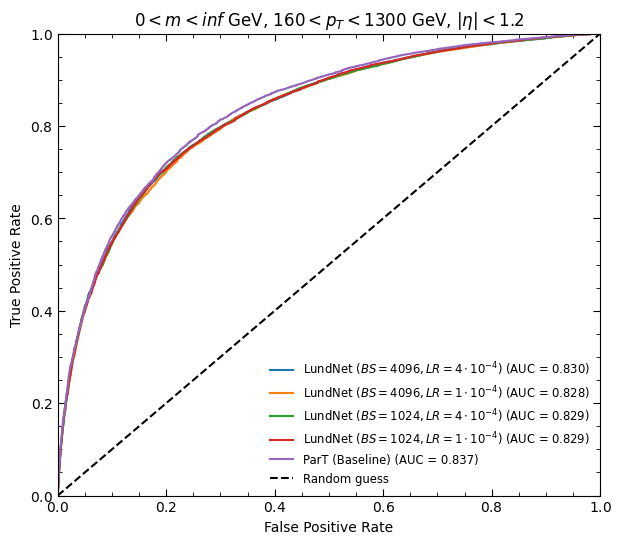

In [23]:
nice_names = {
    "LundNet 2% (4500 Batch, 4.0e-4 LR)": r"LundNet ($BS=4096, LR=4\cdot 10^{-4}$)",
    "LundNet 2% (1.0e-4 LR)":             r"LundNet ($BS=4096, LR=1\cdot 10^{-4}$)",
    "LundNet 2% (1024 Batch)":            r"LundNet ($BS=1024, LR=4\cdot 10^{-4}$)",
    "LundNet 2% (1024 Batch, 1.0e-4 LR)": r"LundNet ($BS=1024, LR=1\cdot 10^{-4}$)",
    "ParT (Baseline)":                    r"ParT (Baseline)"
}

for mass_cut in mass_cuts:
    m_min, m_max = mass_cut
    # Using consistent kinematic cuts logic
    cuts = (mass > m_min) & (mass < m_max) & (pt > pt_min) & (pt < pt_max) & (np.abs(eta) < eta_max) & (np.abs(eta) > eta_min)
    
    y_truth_cuts = data["labels"][cuts]
    weights_cuts = weights[cuts]

    plt.figure(figsize=(7, 6), dpi=100)

    for trained_model in models:
        # Extract predictions for events passing the cuts
        y_pred = models[trained_model]["scores"][cuts]
        
        fpr, tpr, thresholds = roc_curve(y_truth_cuts, y_pred, sample_weight=weights_cuts)
        roc_auc = auc(fpr, tpr)

        # Store results for subsequent background rejection plots
        models[trained_model][f"fpr_{m_min}-{m_max}"] = fpr
        models[trained_model][f"tpr_{m_min}-{m_max}"] = tpr

        # Use the mapping to get the clean name
        display_name = nice_names.get(trained_model, trained_model)
        
        # Consistent label with 3-decimal precision for AUC
        plt.plot(fpr, tpr, label=fr"{display_name} (AUC = {roc_auc:.3f})")

    # Standard diagonal reference line
    plt.plot([0, 1], [0, 1], "--", label="Random guess", color="black")

    # Consistent LaTeX title and axis labels
    plt.title(fr"${m_min} < m < {m_max}$ GeV, ${pt_min} < p_T < {pt_max}$ GeV, $|\eta| < {eta_max}$")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    
    # Legend formatting: no frame and small font
    plt.legend(loc="lower right", frameon=False, fontsize='small')
    plt.show()

/tmp/ipykernel_198978/3718311364.py:24: RuntimeWarning: divide by zero encountered in divide
  ax1.plot(tpr, 1/fpr, label=display_name, color=f"C{i}")


/tmp/ipykernel_198978/3718311364.py:50: RuntimeWarning: divide by zero encountered in divide
  interp_rej = np.interp(ref_tpr, tpr, 1/fpr, left=np.nan, right=np.nan)
/tmp/ipykernel_198978/3718311364.py:51: RuntimeWarning: divide by zero encountered in divide
  ref_rej = 1/ref_fpr
/tmp/ipykernel_198978/3718311364.py:52: RuntimeWarning: invalid value encountered in divide
  ratio = interp_rej / ref_rej


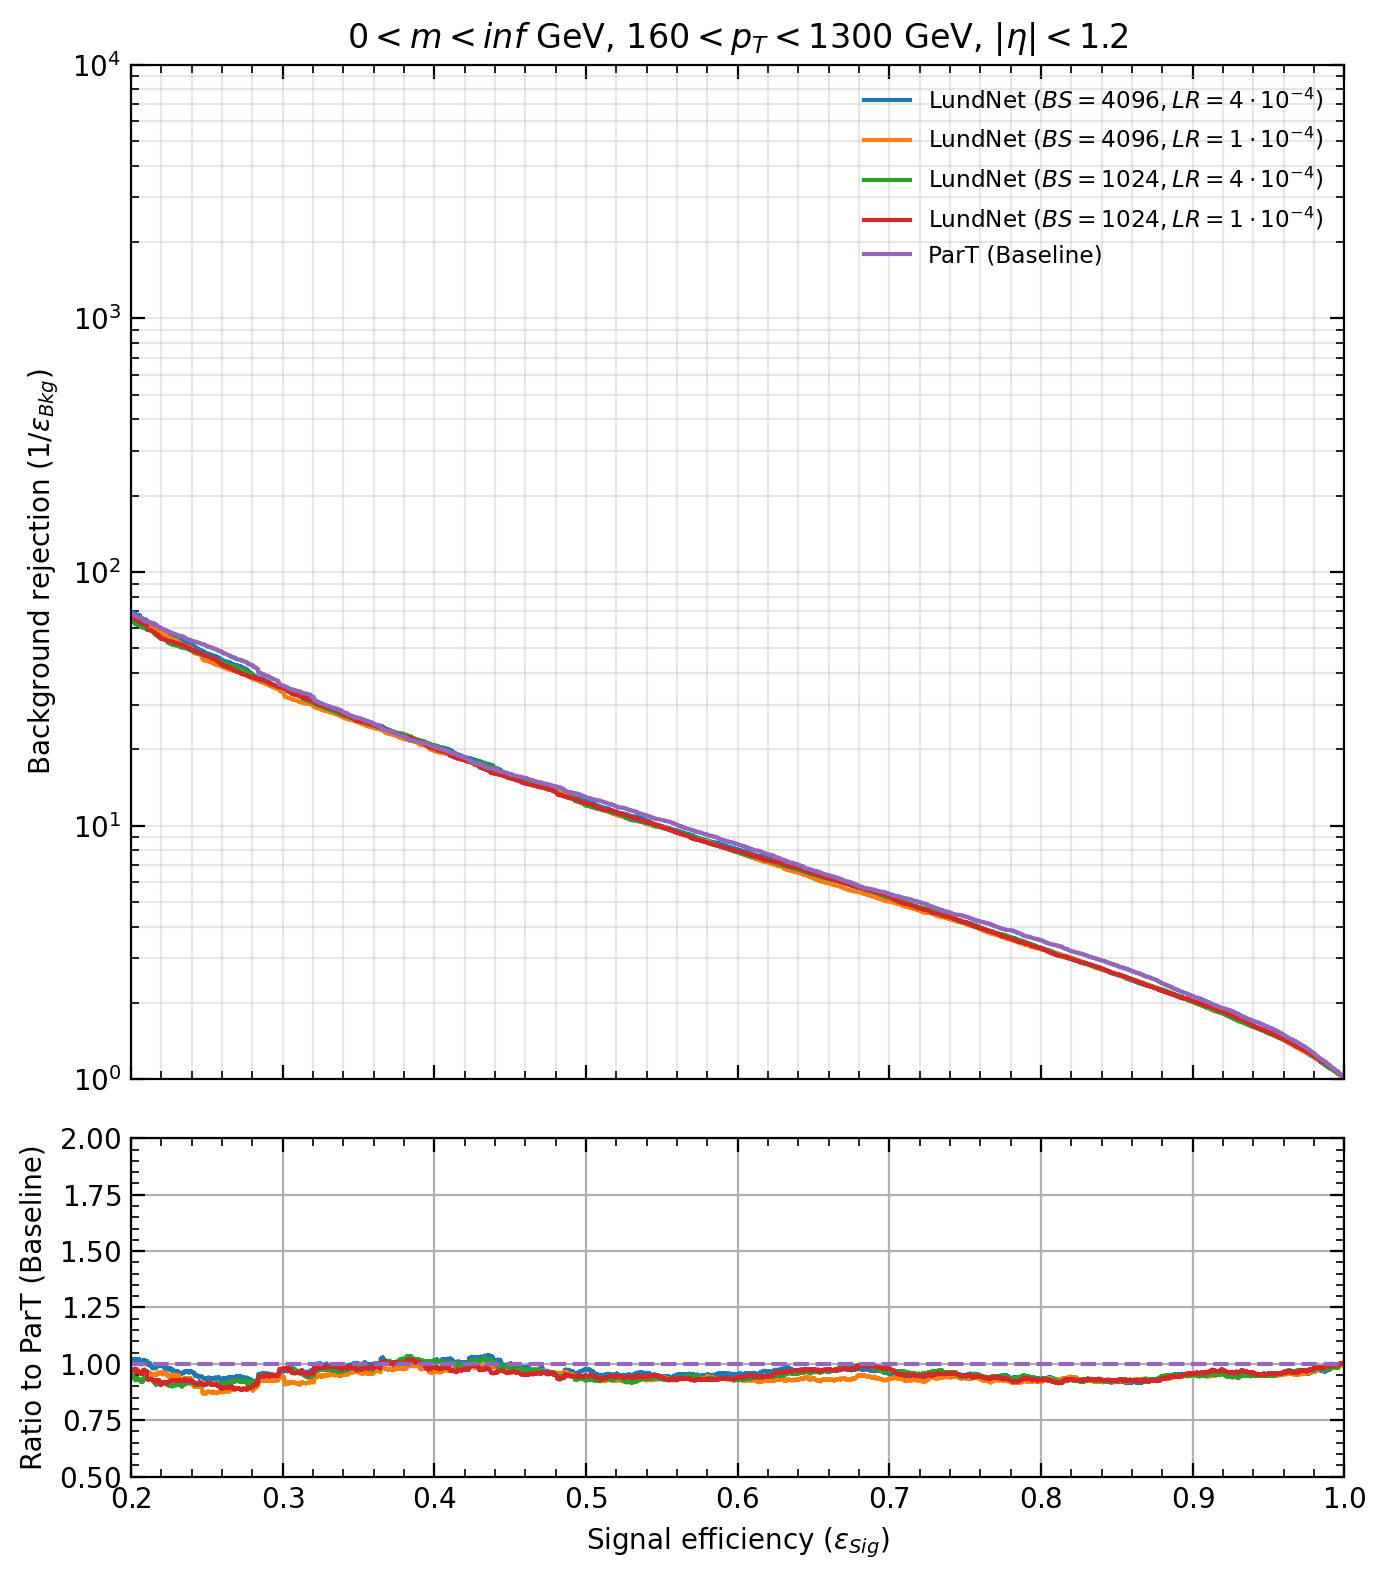

In [24]:
# 1. Configuration
reference_model = "ParT (Baseline)"
selected_models = models.keys()
show_grid = True
plot_ratio = True

for mass_cut in mass_cuts:
    m_min, m_max = mass_cut

    if plot_ratio:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True, dpi=200)
    else:
        fig, ax1 = plt.subplots(figsize=(6, 6), dpi=200)

    # Main Plot Loop
    for i, trained_model in enumerate(selected_models):
        fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
        tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
        
        # Consistent clean naming
        display_name = nice_names.get(trained_model, trained_model)
        
        # Plot Background Rejection with color syncing
        ax1.plot(tpr, 1/fpr, label=display_name, color=f"C{i}")

    # Standardized Main Plot Formatting
    ax1.set_title(fr"${m_min} < m < {m_max}$ GeV, ${pt_min} < p_T < {pt_max}$ GeV, $|\eta| < {eta_max}$")
    ax1.set_ylabel(r"Background rejection ($1/\epsilon_{Bkg}$)")
    ax1.set_xlim([0.2, 1])
    ax1.set_ylim([1, 1e4])
    ax1.set_yscale("log")
    ax1.legend(frameon=False, fontsize='small')
    ax1.grid(show_grid, which='both', alpha=0.3)

    # Standardized Ratio Subplot
    if plot_ratio:
        ref_fpr = models[reference_model][f"fpr_{m_min}-{m_max}"]
        ref_tpr = models[reference_model][f"tpr_{m_min}-{m_max}"]

        for i, trained_model in enumerate(selected_models):
            color = f"C{i}"
            if trained_model == reference_model:
                ax2.axhline(1, color=color, ls="--")
                continue
                
            fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
            tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
            
            # Interpolate to reference tpr points
            interp_rej = np.interp(ref_tpr, tpr, 1/fpr, left=np.nan, right=np.nan)
            ref_rej = 1/ref_fpr
            ratio = interp_rej / ref_rej
            
            ax2.plot(ref_tpr, ratio, color=color)

        ax2.set_xlabel(r"Signal efficiency ($\epsilon_{Sig}$)")
        ax2.set_ylabel(f"Ratio to {nice_names.get(reference_model, reference_model)}")
        ax2.set_ylim([0.5, 2])
        ax2.grid(show_grid)

    plt.tight_layout()
    plt.show()

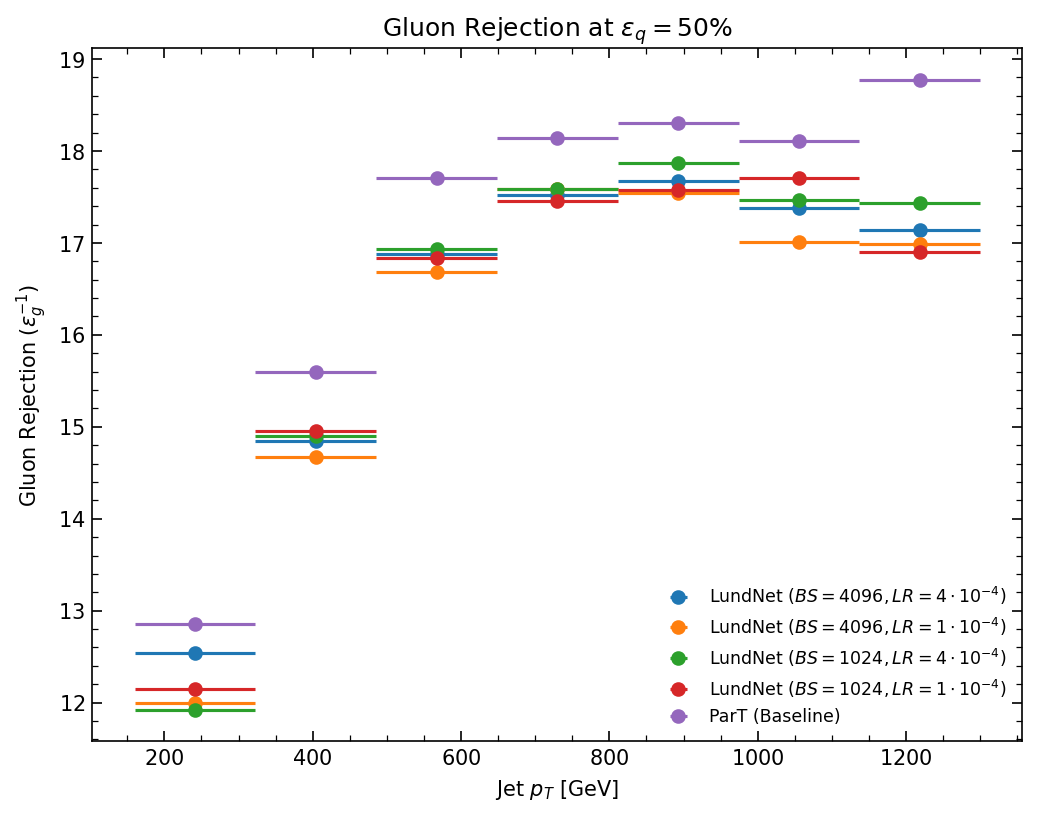

In [25]:
def plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5):
    """
    Standardized Gluon Rejection vs pT for dissertation.
    Uses global 'nice_names' for labeling and excludes y-axis uncertainties.
    """
    pt = data["fjet_pt"]
    labels = data["labels"]
    
    bin_centers = (pt_bins[:-1] + pt_bins[1:]) / 2
    bin_half_widths = (pt_bins[1:] - pt_bins[:-1]) / 2
    
    plt.figure(figsize=(8, 6), dpi=150)
    
    for model_name in models:
        if model_name not in models: continue
        scores = models[model_name]["scores"]
        rejections = []
        valid_centers = []
        valid_xerr = []
        
        # Pull clean label from the global nice_names dictionary
        label_name = nice_names.get(model_name, model_name)
        
        for i in range(len(pt_bins)-1):
            p_min, p_max = pt_bins[i], pt_bins[i+1]
            mask = (pt >= p_min) & (pt < p_max)
            
            if np.sum(mask) < 10: continue
            
            y_true = ak.to_numpy(labels[mask])
            y_score = ak.to_numpy(scores[mask])
            w = ak.to_numpy(weights[mask])
            
            if len(np.unique(y_true)) < 2: continue
            
            # Split into signal and background
            sig_mask = (y_true == 1)
            bkg_mask = (y_true == 0)
            
            s_scores = y_score[sig_mask]
            s_weights = w[sig_mask]
            b_scores = y_score[bkg_mask]
            b_weights = w[bkg_mask]
            
            if len(s_scores) == 0 or len(b_scores) == 0: continue
            
            # 1. Determine Threshold from Signal (Weighted)
            sorter = np.argsort(s_scores)
            s_scores_sorted = s_scores[sorter]
            s_weights_sorted = s_weights[sorter]
            
            cum_w = np.cumsum(s_weights_sorted)
            total_s_w = cum_w[-1]
            target_w = total_s_w * (1 - signal_efficiency)
            idx = np.searchsorted(cum_w, target_w)
            threshold = s_scores_sorted[min(idx, len(s_scores_sorted)-1)]
            
            # 2. Calculate Background Efficiency (FPR)
            pass_mask = b_scores > threshold
            W_total = np.sum(b_weights)
            W_pass = np.sum(b_weights[pass_mask])
            
            if W_pass == 0: continue
                
            epsilon_g = W_pass / W_total
            rejection = 1.0 / epsilon_g
            
            rejections.append(rejection)
            valid_centers.append(bin_centers[i])
            valid_xerr.append(bin_half_widths[i])
            
        # Plot with horizontal bin-width bars only
        plt.errorbar(valid_centers, rejections, xerr=valid_xerr, 
                     fmt='o', label=label_name, capsize=0, elinewidth=1.5)
        
    plt.xlabel(r"Jet $p_T$ [GeV]")
    plt.ylabel(r"Gluon Rejection ($\epsilon_{g}^{-1}$)")
    
    # Standard dissertation style: No log scale (unless ParT squashes others), no frame
    plt.legend(frameon=False, fontsize='small')
    plt.title(r"Gluon Rejection at $\epsilon_{q} = 50\%$")
    plt.show()

# Standardized call
pt_bins = np.linspace(160, 1300, 8)
plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5)

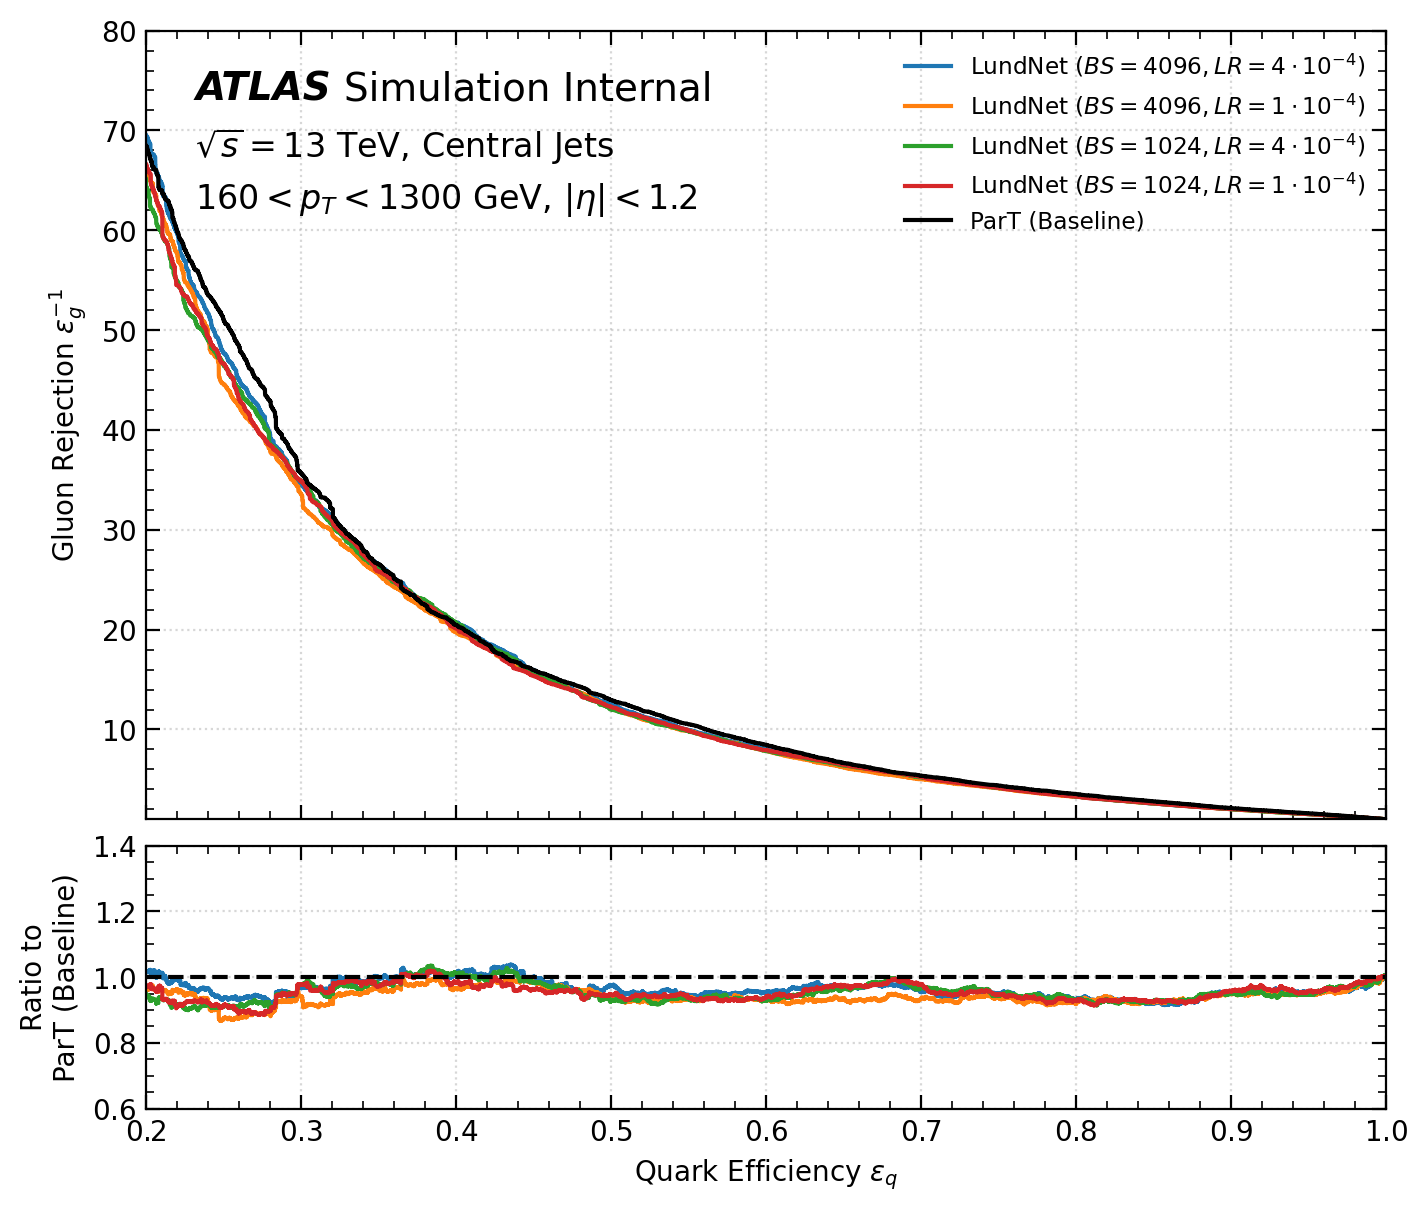

In [28]:
from matplotlib.ticker import MultipleLocator

# 1. Configuration - Use the clean names for reference
reference_model = "ParT (Baseline)" 
selected_models = models.keys()
show_grid = True
plot_ratio = True

# ATLAS-standard colors
model_colors = {
    "ParT (Baseline)": "black",
    "LundNet": "tab:purple"
}
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for mass_cut in mass_cuts:
    m_min, m_max = mass_cut

    if plot_ratio:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}, sharex=True, dpi=200)
    else:
        fig, ax1 = plt.subplots(figsize=(6, 6), dpi=200)

    for i, trained_model in enumerate(selected_models):
        fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
        tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
        
        display_name = nice_names.get(trained_model, trained_model)
        color = model_colors.get(trained_model, default_colors[i % len(default_colors)])
        
        # Plot Background Rejection (1/FPR)
        ax1.plot(tpr, 1/np.maximum(fpr, 1e-10), label=display_name, color=color, lw=1.5)

    # Main Plot Formatting
    ax1.set_ylabel(r"Gluon Rejection $\epsilon_g^{-1}$")
    ax1.set_xlim([0.2, 1])
    ax1.set_ylim([1, 80]) # Adjusted for visibility; set to 1e4 if needed
    #ax1.set_yscale("log")
    ax1.legend(frameon=False, fontsize='small', loc='upper right')
    
    if show_grid:
        ax1.xaxis.set_major_locator(MultipleLocator(0.1))
        ax1.grid(True, which='major', axis='both', ls=":", alpha=0.5)

    # ATLAS Style Labels
    text_args = {"transform": ax1.transAxes, "va": 'top'}
    ax1.text(0.04, 0.95, "ATLAS", fontsize=14, **text_args, fontweight='bold', style='italic')
    ax1.text(0.16, 0.95, "Simulation Internal", fontsize=14, **text_args)
    ax1.text(0.04, 0.88, r"$\sqrt{s} = 13$ TeV, Central Jets", fontsize=12, **text_args)
    ax1.text(0.04, 0.81, fr"${pt_min} < p_T < {pt_max}$ GeV, $|\eta| < {eta_max}$", fontsize=12, **text_args)

    # Ratio Subplot
    if plot_ratio:
        ref_fpr = models[reference_model][f"fpr_{m_min}-{m_max}"]
        ref_tpr = models[reference_model][f"tpr_{m_min}-{m_max}"]

        for i, trained_model in enumerate(selected_models):
            color = model_colors.get(trained_model, default_colors[i % len(default_colors)])
            
            if trained_model == reference_model:
                ax2.axhline(1, color=color, ls="--")
                continue
                
            fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
            tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
            
            # Interpolate model rej to reference TPR points
            interp_rej = np.interp(ref_tpr, tpr, 1/np.maximum(fpr, 1e-10), left=np.nan, right=np.nan)
            ref_rej = 1/np.maximum(ref_fpr, 1e-10)
            
            ax2.plot(ref_tpr, interp_rej / ref_rej, color=color)

        ax2.set_xlabel(r"Quark Efficiency $\epsilon_q$")
        ax2.set_ylabel(f"Ratio to\n{nice_names.get(reference_model, reference_model)}")
        ax2.set_ylim([0.6, 1.4]) # Tighten range for dissertation
        if show_grid:
            ax2.xaxis.set_major_locator(MultipleLocator(0.1))
            ax2.grid(True, which='major', axis='both', ls=":", alpha=0.5)

    plt.show()

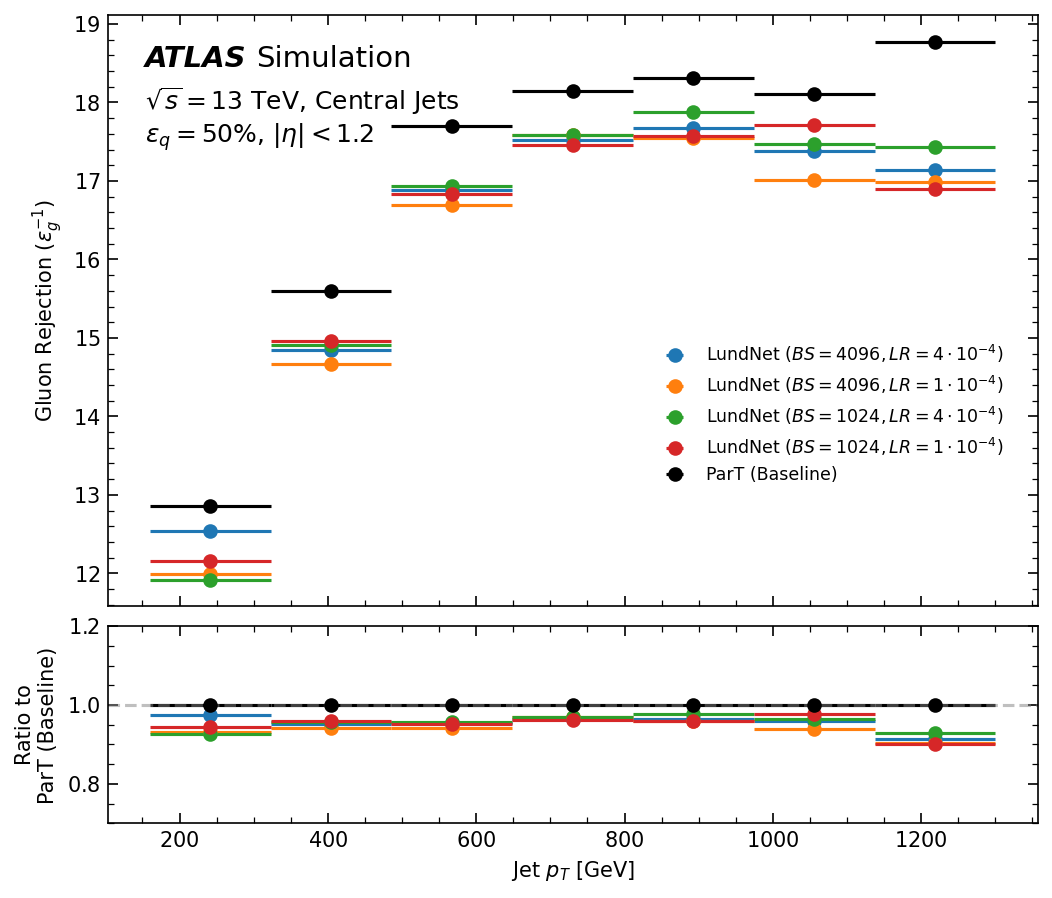

In [27]:
def plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5, reference_model="ParT (Baseline)"):
    pt = data["fjet_pt"]
    labels = data["labels"]
    bin_centers = (pt_bins[:-1] + pt_bins[1:]) / 2
    bin_half_widths = (pt_bins[1:] - pt_bins[:-1]) / 2
    
    # ATLAS-style color map
    model_colors = {"ParT (Baseline)": "black", "LundNet": "tab:purple"}
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 7), dpi=150, sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    
    model_rejections = {}
    
    for i, model_name in enumerate(models):
        scores = models[model_name]["scores"]
        rejections = []
        color = model_colors.get(model_name, default_colors[i % len(default_colors)])
        label_name = nice_names.get(model_name, model_name)
        
        for i_bin in range(len(pt_bins)-1):
            mask = (pt >= pt_bins[i_bin]) & (pt < pt_bins[i_bin+1])
            if np.sum(mask) < 10: 
                rejections.append(np.nan); continue
            
            y_true = ak.to_numpy(labels[mask])
            y_score = ak.to_numpy(scores[mask]); w = ak.to_numpy(weights[mask])
            
            s_mask, b_mask = (y_true == 1), (y_true == 0)
            if not (any(s_mask) and any(b_mask)):
                rejections.append(np.nan); continue

            # Determine Threshold
            s_scores, s_w = y_score[s_mask], w[s_mask]
            idx = np.argsort(s_scores)
            cum_w = np.cumsum(s_w[idx])
            thresh = s_scores[idx][np.searchsorted(cum_w, cum_w[-1]*(1-signal_efficiency))]
            
            # Calculate Rejection
            eps_g = np.sum(w[b_mask & (y_score > thresh)]) / np.sum(w[b_mask])
            rejections.append(1.0/eps_g if eps_g > 0 else np.nan)
            
        rejs = np.array(rejections)
        model_rejections[model_name] = rejs
        
        mask = ~np.isnan(rejs)
        ax0.errorbar(bin_centers[mask], rejs[mask], xerr=bin_half_widths[mask], 
                     fmt='o', label=label_name, color=color, capsize=0, elinewidth=1.5)

    # Main plot formatting
    ax0.set_ylabel(r"Gluon Rejection ($\epsilon_{g}^{-1}$)")
    ax0.legend(frameon=False, loc='upper right', fontsize='small')
    
    # ATLAS Branding
    text_args = {"transform": ax0.transAxes, "va": 'top'}
    ax0.text(0.04, 0.95, "ATLAS", fontsize=14, **text_args, fontweight='bold', style='italic')
    ax0.text(0.16, 0.95, "Simulation", fontsize=14, **text_args)
    ax0.text(0.04, 0.88, r"$\sqrt{s} = 13$ TeV, Central Jets", fontsize=12, **text_args)
    ax0.text(0.04, 0.82, f"$\epsilon_q = {int(signal_efficiency*100)}\%$, $|\eta| < 1.2$", fontsize=12, **text_args)

    # Ratio Plot logic
    if reference_model in model_rejections:
        ref_rej = model_rejections[reference_model]
        for i, model_name in enumerate(models):
            color = model_colors.get(model_name, default_colors[i % len(default_colors)])
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = model_rejections[model_name] / ref_rej
            
            mask = ~np.isnan(ratio)
            ax1.errorbar(bin_centers[mask], ratio[mask], xerr=bin_half_widths[mask], 
                         fmt='o', color=color, capsize=0, elinewidth=1.5)
        ax1.set_ylabel(f"Ratio to\n{nice_names.get(reference_model, reference_model)}")
    
    ax1.set_xlabel(r"Jet $p_T$ [GeV]")
    ax1.set_ylim(0.7, 1.2)
    ax1.axhline(1, color='gray', linestyle='--', alpha=0.5)
    ax0.legend(
        frameon=False, 
        loc='lower right', 
        bbox_to_anchor=(0.98, 0.18), # (x, y) coordinates from 0 to 1
        fontsize='small'
    )
    plt.show()

# Run the plot
pt_bins = np.linspace(160, 1300, 8)
plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5)